In [1]:
from pathlib import Path
from decord import VideoReader,cpu
import matplotlib.pyplot as plt
import torch
from utils.helper_functions import plot_images,get_samples_from_dataset
from torchvision.transforms import v2

In [2]:
ROOT=Path.cwd()
dataset_dir=ROOT/"datasets"/"resized_warehouse_actions"

In [3]:
frames=get_samples_from_dataset(dataset_dir)

In [4]:
from data.transform import VideoTrainTransform,VideoValTransform

In [4]:
tensor_frames=torch.from_numpy(frames).permute(0,3,1,2)
tensor_frames.shape

torch.Size([10, 3, 456, 256])

In [14]:
transformed_frames=VideoTrainTransform(brightness=0.4,saturation=0.2,hue=0.1)(tensor_frames)
transformed_frames.shape

torch.Size([15, 3, 96, 96])

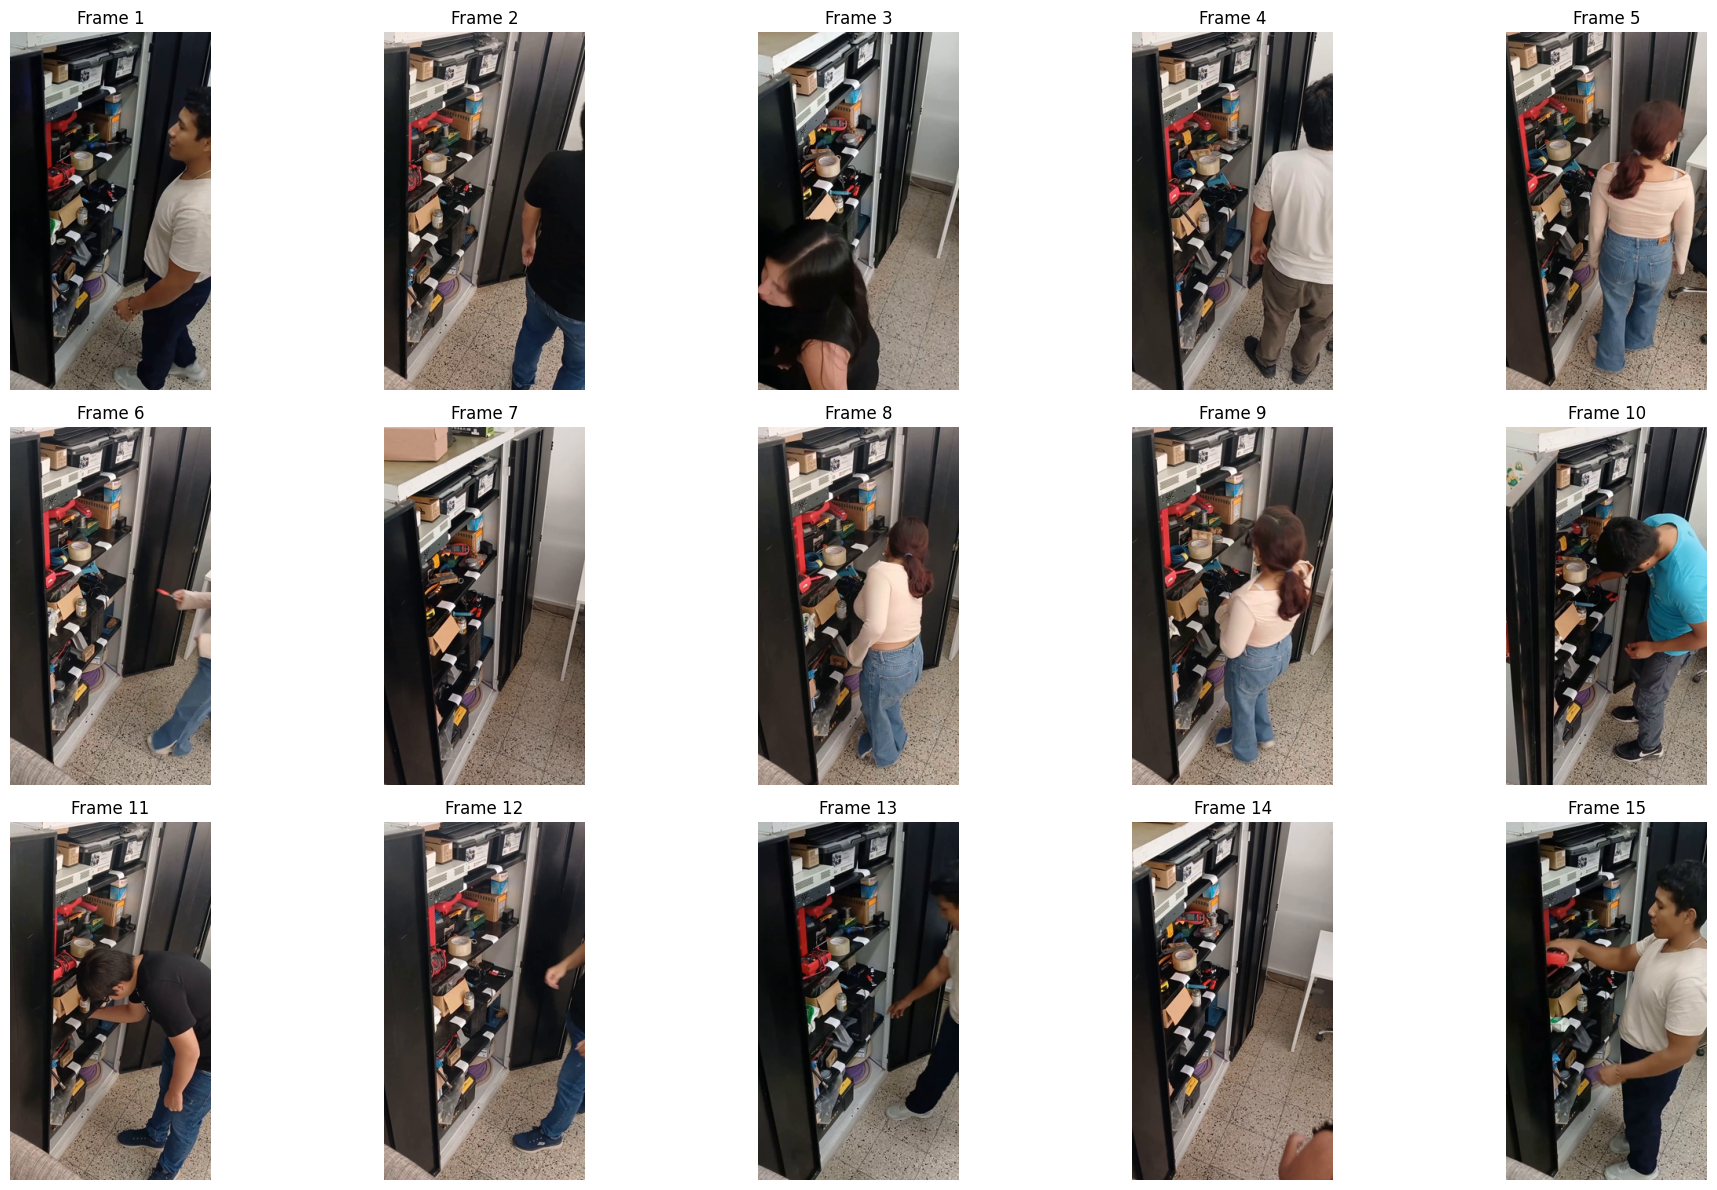

In [15]:
plot_images(frames,3,5)

In [16]:
def denormalize(images, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """
    images: tensor (N, C, H, W)
    mean: lista de 3 valores
    std: lista de 3 valores
    """
    mean = torch.tensor(mean, device=images.device).view(1, 3, 1, 1)
    std = torch.tensor(std, device=images.device).view(1, 3, 1, 1)
    return images * std + mean

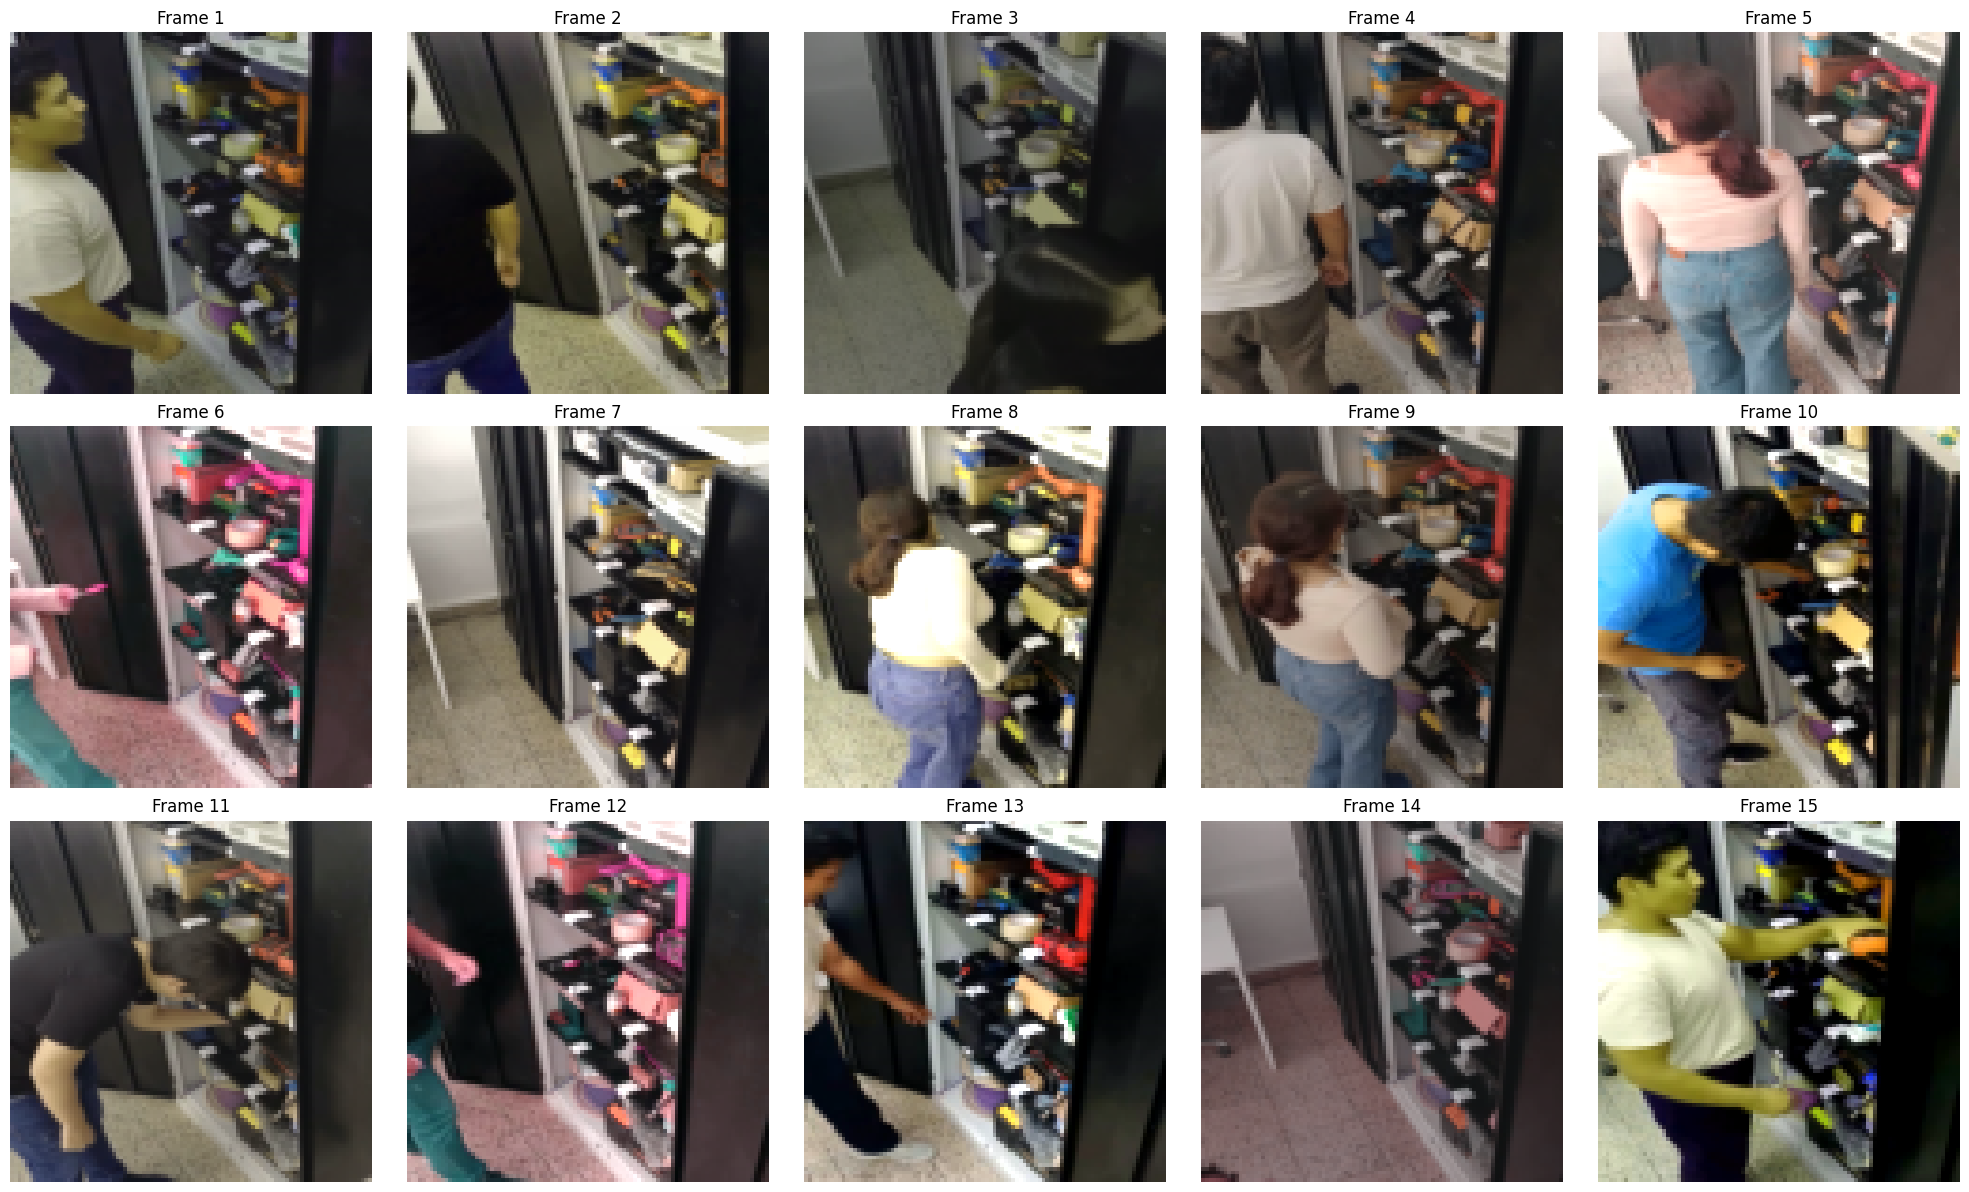

In [17]:
plot_images(denormalize(transformed_frames).permute(0,2,3,1),3,5)